In [53]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('/content/drive/MyDrive/nova_pay_combined.csv')
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [9]:
df.shape

(11400, 26)

In [10]:
df.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='object')

DATA DICTIONARY FOR NOVA PAY TRANSACTION DATASET

This is an explanation of each field in the dataset.





| Column Name | Data Type | Description | Example |
|-------------|-----------|-------------|---------|
| transaction_id | String | Unique identifier for each transaction | TXN102345 |
| customer_id | String | Unique identifier for the customer initiating the transaction | CUST5678 |
| timestamp | Datetime | Date and time when the transaction occurred | 2025-11-01 10:23:45 |
| home_country | String | Country where the customer account is registered | UK |
| source_currency | String | Currency used by the sender | GBP |
| dest_currency | String | Currency received by the recipient | USD |
| channel | Categorical | Platform used for the transaction (mobile, web, API) | mobile |
| amount_src | Float | Transaction amount in the source currency | 500.00 |
| amount_usd | Float | Transaction amount converted to USD | 620.50 |
| fee | Float | Transaction fee charged by the platform | 5.50 |
| exchange_rate_src_to_dest | Float | Exchange rate applied from source to destination currency | 1.24 |
| device_id | String | Unique identifier for the device used | DEV98765 |
| new_device | Binary | Indicates if the device is new (1 = Yes, 0 = No) | 1 |
| ip_address | String | IP address used for the transaction | 192.168.0.1 |
| ip_country | String | Country detected from the IP address | Germany |
| location_mismatch | Binary | Indicates if IP country differs from home country | 1 |
| ip_risk_score | Float | Risk score assigned to the IP address | 0.72 |
| kyc_tier | Integer | Customer KYC verification level | 2 |
| account_age_days | Integer | Number of days since account creation | 365 |
| device_trust_score | Float | Trust score assigned to the device | 0.85 |
| chargeback_history_count | Integer | Number of previous chargebacks | 1 |
| risk_score_internal | Float | Internal fraud risk score | 0.67 |
| txn_velocity_1h | Integer | Number of transactions in the past 1 hour | 3 |
| txn_velocity_24h | Integer | Number of transactions in the past 24 hours | 12 |
| corridor_risk | Float | Risk score of the country transaction corridor | 0.55 |
| is_fraud | Binary | Fraud label (1 = Fraud, 0 = Legitimate) | 0 |

In [11]:
#checking for missing data
df.isnull().sum()

,0
transaction_id,0
customer_id,0
timestamp,29
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,0
amount_usd,305
fee,295


Checking the missing values in each variable, we can confirm that:

- timestamp has 29 missing values

- amount_usd has 305 missing values

- fee has 295 missing values

- ip_address has 305 missing values

- ip_country has 301 missing values

- kyc_tier has 300 missing values

- device_trust_score has 295 missing values

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  object 
 1   customer_id                11400 non-null  object 
 2   timestamp                  11371 non-null  object 
 3   home_country               11400 non-null  object 
 4   source_currency            11400 non-null  object 
 5   dest_currency              11400 non-null  object 
 6   channel                    11400 non-null  object 
 7   amount_src                 11400 non-null  object 
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  object 
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  obj

From the above inspection we can see that timestamp is stored as a wrong data type, an object data type instead of datetime format. Also amount_src variable is also stored as object data type rather than float or integer.

In [13]:
df['timestamp'].value_counts(dropna=False).head(20)

,count
timestamp,
NaN,29
0000-00-00T00:00:00Z,21
2025/13/40 25:61:00,11
2024-12-08 20:25:58.468549+00:00,2
2023-07-21 03:56:58.468549+00:00,2
2024-01-22 00:24:24.468549+00:00,2
2024-12-14 08:44:42.468549+00:00,2
2024-10-14 15:56:36.468549+00:00,2
2024-08-05 08:46:02.468549+00:00,2


From our value_counts we can see that 32 datas has inavlid timestamp which will lead to nan values when the data type is converted

In [14]:
df['amount_src'].dtype

dtype('O')

In [15]:
df['amount_src'].unique()[:20]

array(['278.19', '208.51', '160.33', '59.41', '200.96', '526.9', '149.24',
       '276.51', '99.52', '302.55', '187.84', '9998.43', '171.86',
       '322.24', '87.81', '9991.85', '309.39', '260.49', '87.5', '254.76'],
      dtype=object)

In [16]:
df['amount_src'].value_counts(dropna=False).head(20)

,count
amount_src,
100.0,15
102.29,5
144.29,4
261.23,4
102.37,4
82.25,4
115.29,4
119.15,4
94.34,4


In [17]:
#checking for label imbalance
df['is_fraud'].value_counts(normalize=True).reset_index()

,is_fraud,proportion
0,0,0.912544
1,1,0.087456


The is_fraud variable which happens to be our target variable is unevenly distributed. About 91% of the target variable confirms transaction is legitimate while 9% confirms that transaction is_fraud.

**SUMMARY/OBSERVATIONS**

- The composition of the dataset is 11400 rows and 26 columns

- All fieldnames follows the standard variable naming conventions

- An initial inspection of the dataset revealed inconsistencies in the data types of certain variables. Specifically, the timestamp variable is currently stored as an object data type instead of the appropriate datetime format, which is necessary for accurate time-based analysis. Similarly, the amount_src variable is also stored as an object data type, whereas it should ideally be represented as a numeric format (integer or float) to allow for proper numerical computations and analysis. These inconsistencies will need to be corrected during the data preprocessing stage.

- An assessment of missing values across the dataset revealed that several variables contain incomplete records. Specifically, the timestamp variable contains 29 missing values, while amount_usd and ip_address each contain 305 missing values. Additionally, the fee and device_trust_score variables both have 295 missing values, ip_country has 301 missing values, and kyc_tier contains 300 missing values. These missing values will require appropriate data cleaning and preprocessing to ensure the reliability and accuracy of subsequent analysis and modeling.

- The target variable is_fraud is highly imbalanced, with approximately 91% of transactions classified as legitimate and only 9% identified as fraudulent. This imbalance introduces a risk of model bias toward the majority class, where machine learning algorithms may prioritize predicting legitimate transactions while failing to detect fraudulent ones. As a result, relying solely on accuracy could produce misleading results. To mitigate this issue, techniques such as resampling methods and appropriate evaluation metrics should be used to ensure the model effectively identifies fraudulent transactions.

DATA CLEANING AND PREPARATION

In [18]:
#converting data types of timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'],errors='coerce')
#converting data type of income_usd to float
df['amount_src'] = pd.to_numeric(df['amount_src'],errors='coerce')


In [19]:
#checking the dataset again to confirm the data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             11400 non-null  object             
 1   customer_id                11400 non-null  object             
 2   timestamp                  11339 non-null  datetime64[ns, UTC]
 3   home_country               11400 non-null  object             
 4   source_currency            11400 non-null  object             
 5   dest_currency              11400 non-null  object             
 6   channel                    11400 non-null  object             
 7   amount_src                 11396 non-null  float64            
 8   amount_usd                 11095 non-null  float64            
 9   fee                        11105 non-null  float64            
 10  exchange_rate_src_to_dest  11400 non-null  float64            
 11  de

During data preprocessing, the timestamp and amount_src variables were converted to appropriate data types using pd.to_datetime() and pd.to_numeric() with the errors='coerce' argument. This process revealed additional invalid entries that could not be parsed correctly, resulting in an increase in missing values. Specifically, the number of missing values in timestamp increased from 29 to 61, while amount_src increased from 0 to 4. These additional missing values indicate the presence of improperly formatted or corrupted records, which were subsequently handled during the data cleaning stage.

In [20]:
# Rechecking for missing data
df.isnull().sum()

,0
transaction_id,0
customer_id,0
timestamp,61
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,4
amount_usd,305
fee,295


VARIABLES WITH MISSING VALUES THAT NEEDS IMPUTATION

- amount_usd: has 305 missing values. this will be filled by multiplying the amount_src by the exchange rate of the currency

- fee: has 295 missing values which will be filled by the median of channel variable if channel exists while other remaining fee missing values will be filled using the overall median.

- ip_country: has 301 missing values which will be filled by the corresponding home_country.

- kyc_tier: has 300 missing values which will be filled with the most frequent kyc_tier(mode).

- device_trust_score: has 295 missing values. This will be filled by the median of the group from grouping device_trust_score by kyc_tier and new_device variable or by the overall median of device_trust_score.

The timestamp variable which has 61 missing values and amount_src with 4 missing values will be dropped using the dropna method because the number of missing values in both variables is very small compared to the values we have on our dataset. The ip_address variable has missing values of 305 cannot be filled with any value as each ip_address is a unique number so it will be dropped using the dropna method.

In [21]:
#calculating exchange rates per currency
exchange_rates = df[df['amount_usd'].notna()].groupby('source_currency').apply(
    lambda x: (x['amount_usd'] / x['amount_src']).mean()
).to_dict()
exchange_rates

/tmp/ipykernel_191/2187916205.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  exchange_rates = df[df['amount_usd'].notna()].groupby('source_currency').apply(


{'CAD': 0.7216095926871465,
 'GBP': 1.223441221648679,
 'USD': 0.9838730321259439}

In [22]:
#filling the missing values of the amount_usd
df['amount_usd']=df.apply(
    lambda row: row['amount_usd'] if pd.notna(row['amount_usd']) else row['amount_src'] * exchange_rates.get(row['source_currency'],1),
    axis=1
)

In [23]:
# filling the missing values of the fee variable
if 'fee' in df.columns:
  if 'channel' in df.columns:
    df['fee'] = df.groupby('channel')['fee'].transform(lambda y: y.fillna(y.median()))
  df['fee'] = df['fee'].fillna(df['fee'].median())

In [24]:
# filling the missing values of ip_country variable
if {'ip_country', 'home_country'}.issubset(df.columns):
  df['ip_country'] = df['ip_country'].fillna(df['home_country'])

In [25]:
# filling the missing values of kyc_tier variable
if 'kyc_tier' in df.columns:
  df['kyc_tier'] = df['kyc_tier'].fillna(df['kyc_tier'].mode()[0])

In [26]:
# filling the missing values of device_trust_score variable
if 'device_trust_score' in df.columns:
  if{'new_device', 'kyc_tier'}.issubset(df.columns):
    df['device_trust_score']=df.groupby(['new_device','kyc_tier'])['device_trust_score'].transform(lambda x: x.fillna(x.median()))
  df['device_trust_score']=df['device_trust_score'].fillna(df['device_trust_score'].median())

In [27]:
# dropping the timestamp, amount_src and ip_address missing values
df.dropna(subset=['timestamp', 'amount_src', 'ip_address'], inplace=True)


In [28]:
# rechecking for missing values
df.isnull().sum()

,0
transaction_id,0
customer_id,0
timestamp,0
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,0
amount_usd,0
fee,0


Now that all missing values have been sorted out we need to do a sanity check i.e check for inconsistency in our dataset.

In [29]:
# checking overall view of each variables using .describe method
df.describe(include='all')

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11030,11030,11030,11030,11030,11030,11030,11030.000000,11030.000000,11030.000000,...,11030.000000,11030,11030.000000,11030.000000,11030.000000,11030.000000,11030.000000,11030.000000,11030.000000,11030.000000
unique,10836,1314,NaN,7,3,9,12,NaN,NaN,NaN,...,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,7e762adf-98c5-48e5-900a-b6afee5ade30,402cccc9-28de-45b3-9af7-cc5302aa1f93,NaN,US,USD,NGN,mobile,NaN,NaN,NaN,...,NaN,standard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1458,NaN,7684,7770,1426,6134,NaN,NaN,NaN,...,NaN,7883,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2024-05-03 10:31:41.290405376+00:00,NaN,NaN,NaN,NaN,437.800284,448.664391,98.222628,...,0.397463,NaN,393.040435,0.654513,0.050045,0.268070,0.470263,0.740073,0.045573,0.089483
min,NaN,NaN,2022-10-03 18:40:59.468549+00:00,NaN,NaN,NaN,NaN,-9997.160000,7.230000,-1.000000,...,0.004000,NaN,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,2023-08-15 02:53:40.468549120+00:00,NaN,NaN,NaN,NaN,90.867500,92.545000,2.390000,...,0.209000,NaN,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,2024-05-09 01:16:28.968549120+00:00,NaN,NaN,NaN,NaN,159.080000,163.590000,3.510000,...,0.325000,NaN,286.500000,0.658000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,2025-01-29 07:26:17.047345408+00:00,NaN,NaN,NaN,NaN,294.940000,302.137500,5.550000,...,0.488000,NaN,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,NaN,NaN,2025-12-16 00:13:41.468549+00:00,NaN,NaN,NaN,NaN,11942.890000,12497.900000,9999.990000,...,1.200000,NaN,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


In [30]:
# checking individual columns
for col in df.columns:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in transaction_id:
['fee8542d-8ee6-4b0d-9671-c294dd08ed26'
 'bfdb9fc1-27fe-4a85-b043-4d813d679259'
 'fc855034-3ea5-4993-9afa-b511d93fe5e8' ...
 '6a51f0e8-f5d1-4fe6-91a0-655fccd79fa5'
 '4aad7389-2b62-4885-a23e-aa3ecd5cfaf9'
 'fdffeb16-192a-4483-9b1e-9928e23269c2']

Unique values in customer_id:
['402cccc9-28de-45b3-9af7-cc5302aa1f93'
 '67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad'
 '6d0d9b27-fa26-45f8-93b1-2df29d182d9c' ...
 '2003e2a1-f3b1-4e2e-8d0e-488cfacf68ca'
 '8b1cf558-4ed7-48ee-b330-75db6efd4840'
 'b69010dc-ab0a-4fd2-a79e-65e4c6efbcd9']

Unique values in timestamp:
<DatetimeArray>
['2022-10-03 18:40:59.468549+00:00', '2022-10-03 20:39:38.468549+00:00',
 '2022-10-03 23:02:43.468549+00:00', '2022-10-04 01:08:53.468549+00:00',
 '2022-10-04 09:35:03.468549+00:00', '2022-10-04 12:09:59.468549+00:00',
 '2022-10-04 12:37:41.468549+00:00', '2022-10-04 16:27:44.468549+00:00',
 '2022-10-04 21:00:36.468549+00:00', '2022-10-04 21:20:42.468549+00:00',
 ...
 '2025-11-24 13:42:17.573611+0

STEPS TO TAKE TO DO THE SANITY CHECK

- Check for invalid numbers i.e negative numbers for variables that contains age, monetary values, velocity etc

- Check if transaction timestamp appear in the future

- Check that values falls between range

- Inspect for inconsistency among variable values in the dataset

In [31]:
# Checking negative values in numeric columns
negative_counts = {
    'amount_src': (df['amount_src'] < 0).sum(),
    'amount_usd': (df['amount_usd'] < 0).sum(),
    'fee': (df['fee'] < 0).sum(),
    'device_trust_score': (df['device_trust_score'] < 0).sum(),
    'txn_velocity_1h': (df['txn_velocity_1h'] < 0).sum(),
    'txn_velocity_24h': (df['txn_velocity_24h'] < 0).sum(),
    'risk_score_internal': (df['risk_score_internal'] < 0).sum(),
}
negative_counts

{'amount_src': np.int64(100),
 'amount_usd': np.int64(0),
 'fee': np.int64(90),
 'device_trust_score': np.int64(190),
 'txn_velocity_1h': np.int64(190),
 'txn_velocity_24h': np.int64(0),
 'risk_score_internal': np.int64(0)}

In [32]:
df = df.drop(df[
    (df['amount_src'] < 0) |
    (df['fee'] < 0) |
    (df['device_trust_score'] < 0) |
    (df['txn_velocity_1h'] < 0)].index)

In [33]:
# Rechecking for negative numbers again
negative_counts = {
    'amount_src': (df['amount_src'] < 0).sum(),
    'amount_usd': (df['amount_usd'] < 0).sum(),
    'fee': (df['fee'] < 0).sum(),
    'device_trust_score': (df['device_trust_score'] < 0).sum(),
    'txn_velocity_1h': (df['txn_velocity_1h'] < 0).sum(),
    'txn_velocity_24h': (df['txn_velocity_24h'] < 0).sum(),
    'risk_score_internal': (df['risk_score_internal'] < 0).sum(),
}
negative_counts

{'amount_src': np.int64(0),
 'amount_usd': np.int64(0),
 'fee': np.int64(0),
 'device_trust_score': np.int64(0),
 'txn_velocity_1h': np.int64(0),
 'txn_velocity_24h': np.int64(0),
 'risk_score_internal': np.int64(0)}

In [34]:
# checking for futuristic timestamp
df[df['timestamp'] > pd.Timestamp.utcnow()]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud


In [35]:
# checking for location mismatch
df['location_mismatch'].value_counts().reset_index()

,location_mismatch,count
0,False,9047
1,True,1793


The above values from the value counts of location_mismatch variable is expected as the project has to do with fraudulent transaction

The channel, source_currency, dest_currency and kyc_tier has inconsistent values in the dataset.

In [36]:
# reviewing the channel variable
df['channel'].unique()

array(['ATM', 'web', 'mobile', 'WEB', ' web  ', 'MOBILE', 'unknown',
       'mobille', ' mobile  ', 'weeb', 'ATm', ' ATM  '], dtype=object)

In [37]:
#formatting the channel variable
df['channel'] = df['channel'].str.lower().str.strip()
df['channel'].unique()

array(['atm', 'web', 'mobile', 'unknown', 'mobille', 'weeb'], dtype=object)

In [38]:
df['channel'] = df['channel'].replace({
    'weeb':'web',
    'mobille':'mobile',
})

In [39]:
df['channel'] = df['channel'].replace({'unknown':np.nan})
df['channel'].unique()

array(['atm', 'web', 'mobile', nan], dtype=object)

In [40]:
# reviewing the source currency variable
df['source_currency'].unique()

array(['USD', 'CAD', 'GBP'], dtype=object)

In [41]:
# reviewing the destination currency variable
df['dest_currency'].unique()

array(['CAD', 'MXN', 'CNY', 'EUR', 'INR', 'GBP', 'PHP', 'NGN', 'USD'],
      dtype=object)

In [42]:
# reviewing the kyc_tier variable
df['kyc_tier'].unique()

array(['standard', 'enhanced', 'low', ' standard  ', 'standrd',
       ' enhanced  ', 'STANDARD', 'unknown', 'enhancd', ' low  ',
       'ENHANCED', 'LOW'], dtype=object)

In [43]:
#formatting the channel variable
df['kyc_tier'] = df['kyc_tier'].str.lower().str.strip()
df['kyc_tier'].unique()

array(['standard', 'enhanced', 'low', 'standrd', 'unknown', 'enhancd'],
      dtype=object)

In [44]:
df['kyc_tier'] = df['kyc_tier'].replace({
    'standrd':'standard',
    'enhancd':'enhanced',
    'unknown': np.nan
})
df['kyc_tier'].unique()

array(['standard', 'enhanced', 'low', nan], dtype=object)

In [45]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
timestamp,0
home_country,0
source_currency,0
dest_currency,0
channel,36
amount_src,0
amount_usd,0
fee,0


After the formatting, we got a few missing values in the channel and kyc_tier variable. These variables will be removed using the dropna method.

In [46]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10780 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             10780 non-null  object             
 1   customer_id                10780 non-null  object             
 2   timestamp                  10780 non-null  datetime64[ns, UTC]
 3   home_country               10780 non-null  object             
 4   source_currency            10780 non-null  object             
 5   dest_currency              10780 non-null  object             
 6   channel                    10780 non-null  object             
 7   amount_src                 10780 non-null  float64            
 8   amount_usd                 10780 non-null  float64            
 9   fee                        10780 non-null  float64            
 10  exchange_rate_src_to_dest  10780 non-null  float64            
 11  device_

In [47]:
# reviewing the home_country variable
df['home_country'].unique()

array(['US', 'CA', 'UK', ' UK  ', ' US  ', 'unknown', ' CA  '],
      dtype=object)

In [50]:
#formatting the home_country variable
df['home_country'] = df['home_country'].str.lower().str.strip()
df['home_country'].unique()

array(['us', 'ca', 'uk', 'unknown'], dtype=object)

In [48]:
# reviewing the ip_country variable
df['ip_country'].unique()

array(['US', 'CA', 'UK', ' US  ', 'unknown', ' CA  ', ' UK  '],
      dtype=object)

In [51]:
#formatting the ip_country variable
df['ip_country'] = df['ip_country'].str.lower().str.strip()
df['ip_country'].unique()

array(['us', 'ca', 'uk', 'unknown'], dtype=object)

From the result of our info method, all missing values, inconsistency and errors has been fixed. String values correctly formatted and data types correctly converted.

EXPLORATORY DATA ANALYSIS

<Axes: xlabel='is_fraud'>

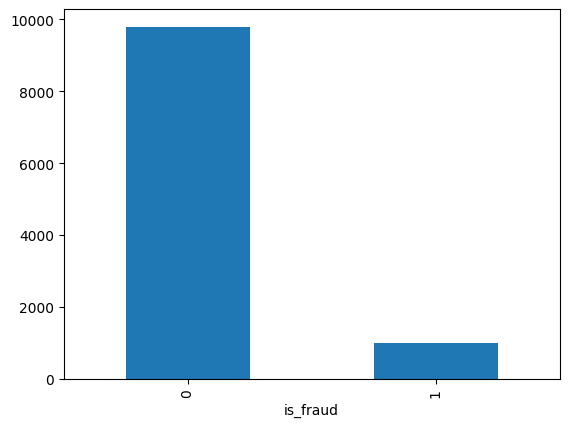

In [52]:
# checking for class imbalance of the target variable 'is_fraud'
df['is_fraud'].value_counts().plot(kind='bar')

<Axes: xlabel='channel'>

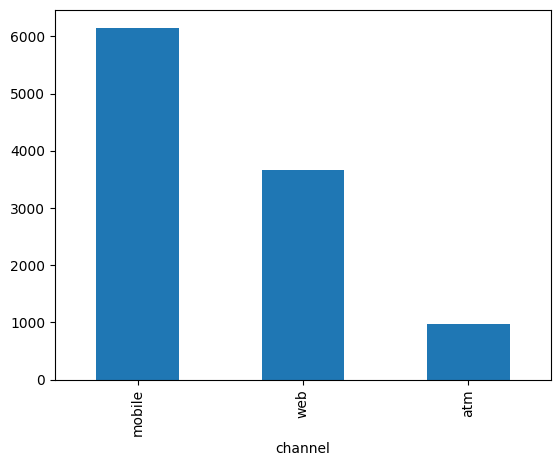

In [54]:
# channel distribution
df['channel'].value_counts().plot(kind='bar')

<Axes: xlabel='location_mismatch'>

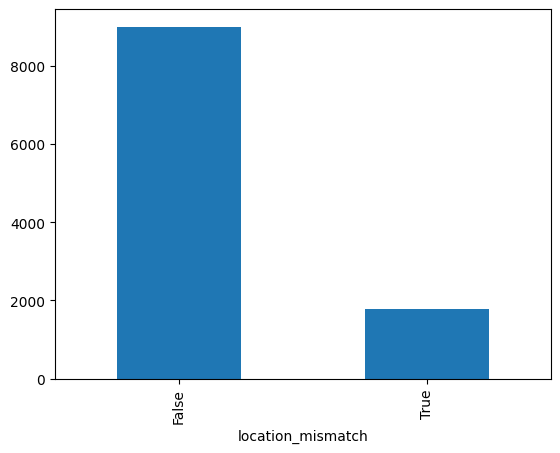

In [55]:
df['location_mismatch'].value_counts().plot(kind='bar')

<Axes: xlabel='ip_country'>

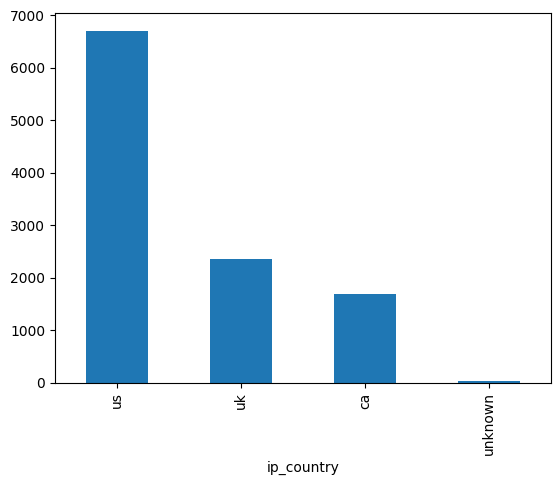

In [56]:
#counts of ip_country
df['ip_country'].value_counts().plot(kind='bar')

<Axes: xlabel='kyc_tier'>

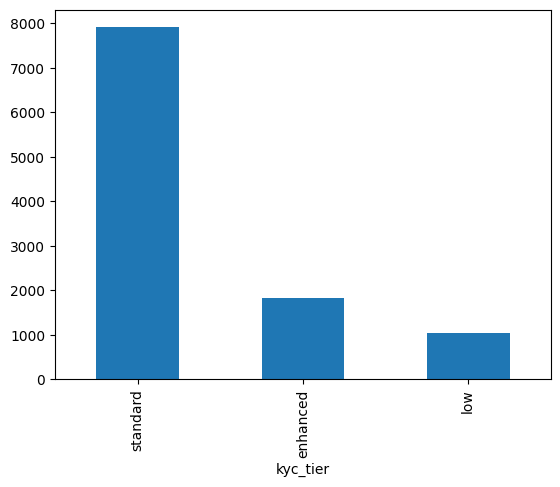

In [57]:
# counts of kyc_tier
df['kyc_tier'].value_counts().plot(kind='bar')

<Axes: xlabel='new_device'>

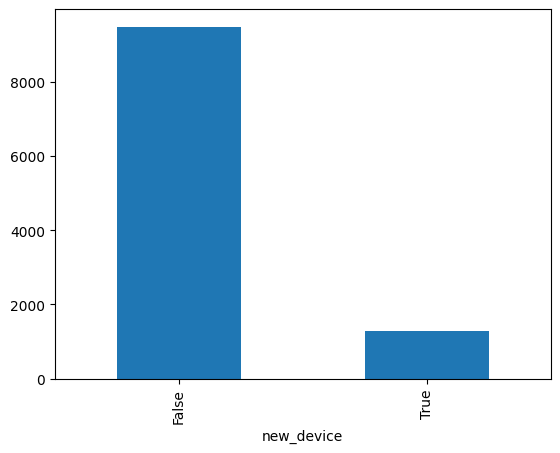

In [58]:
# Counts of new_device
df['new_device'].value_counts().plot(kind='bar')

<Axes: xlabel='source_currency'>

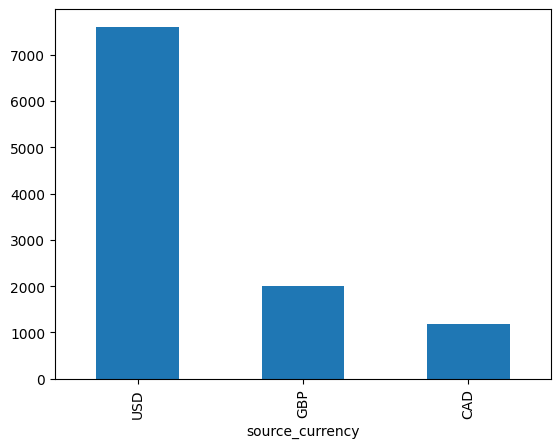

In [60]:
# counts of source_country
df['source_currency'].value_counts().plot(kind='bar')

<Axes: xlabel='dest_currency'>

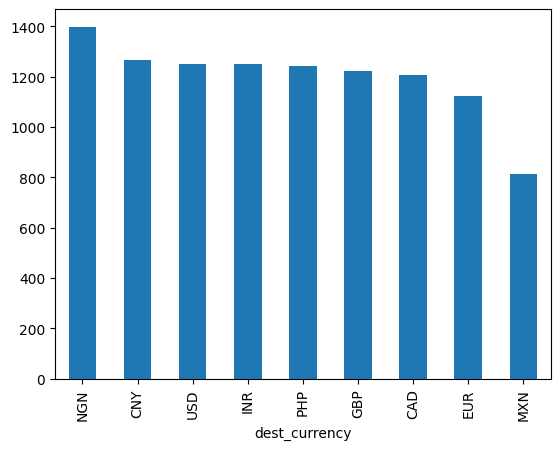

In [61]:
# counts of dest_currency
df['dest_currency'].value_counts().plot(kind='bar')

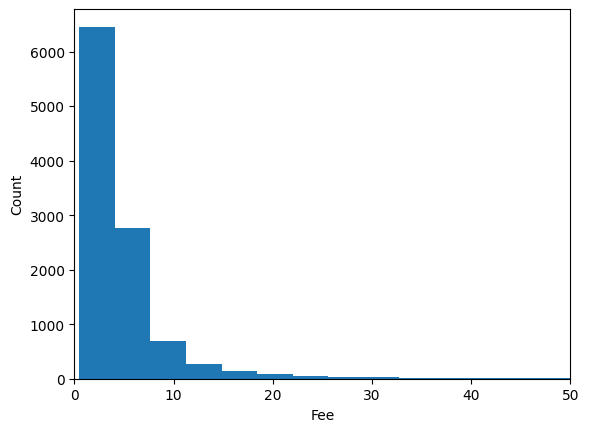

In [66]:
plt.hist(df['fee'], bins=50)
plt.xlim(0,50)
plt.xlabel('Fee')
plt.ylabel('Count')
plt.show()

The histogram shows that the transaction fee distribution is heavily right-skewed, with most transactions having low fees while a few extreme values create outliers at the high end.

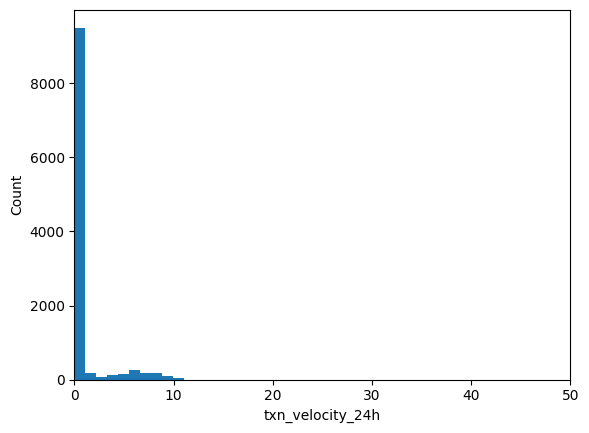

In [75]:
plt.hist(df['txn_velocity_24h'], bins=10)
plt.xlim(0,50)
plt.xlabel('txn_velocity_24h')
plt.ylabel('Count')
plt.show()

The histogram shows that most users perform very few transactions within 24 hours, while a small number of users exhibit unusually high transaction activity, indicating potential outliers or suspicious behavior.

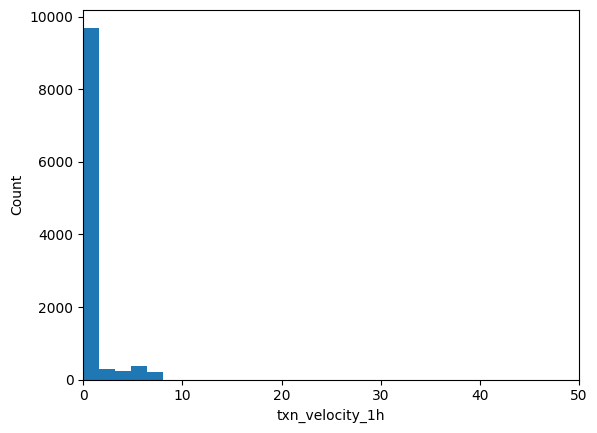

In [78]:
plt.hist(df['txn_velocity_1h'], bins=5)
plt.xlim(0,50)
plt.xlabel('txn_velocity_1h')
plt.ylabel('Count')
plt.show()

This also shows that most users perform very few transactions within an hour, while a small number of users exhibit unusually high transaction activity, indicating potential outliers or suspicious behavior.

BIVARIATE EDA

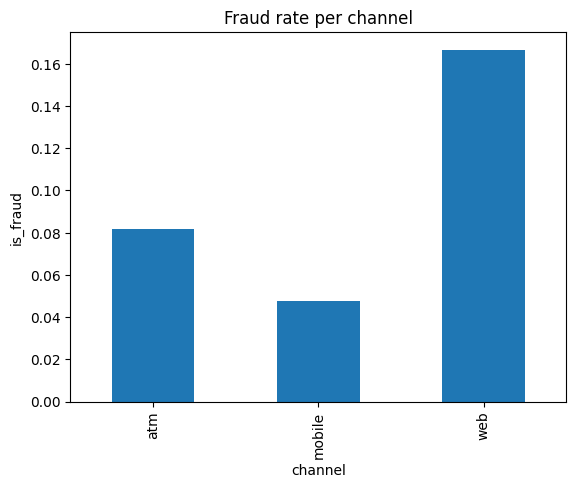

In [89]:
#the chart shows Fraud rate per channel
df.groupby('channel')['is_fraud'].mean().plot(kind='bar')
plt.xlabel('channel')
plt.ylabel('is_fraud')
plt.title('Fraud rate per channel')
plt.show()

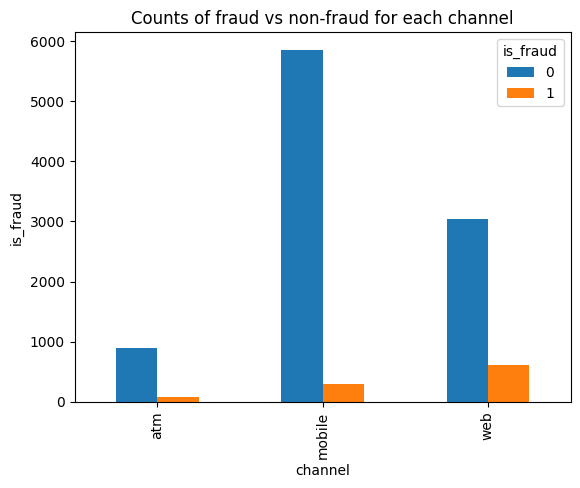

In [88]:
# The chart shows counts of fraud vs non-fraud for each channel.
df.groupby('channel')['is_fraud'].value_counts().unstack().plot(kind='bar', stacked=False)
plt.xlabel('channel')
plt.ylabel('is_fraud')
plt.title('Counts of fraud vs non-fraud for each channel')
plt.show()

The first chart shows fraud risk by measuring fraud rate, Transactions from the web channel have a higher fraud rate than mobile transactions, while the other shows fraud volume by measuring fraud counts by channel. Also transactions from the web channel have a higher fraud rate than mobile transactions.

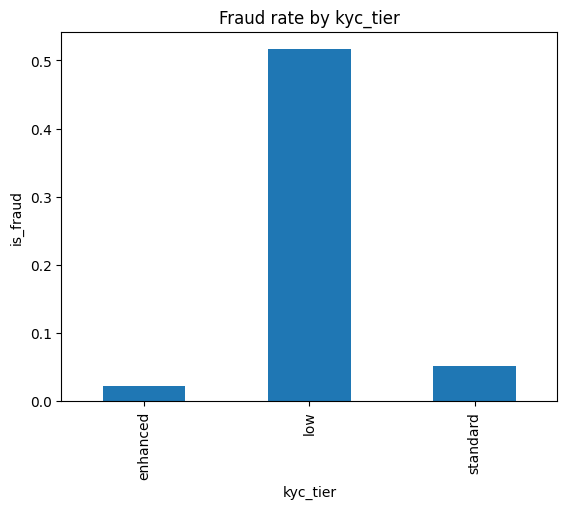

In [90]:
#the chart shows Fraud rate per kyc_tier
df.groupby('kyc_tier')['is_fraud'].mean().plot(kind='bar')
plt.xlabel('kyc_tier')
plt.ylabel('is_fraud')
plt.title('Fraud rate by kyc_tier')
plt.show()

The chart shows that fraud rates are significantly higher among users with low KYC verification, while users with enhanced verification exhibit the lowest fraud risk.

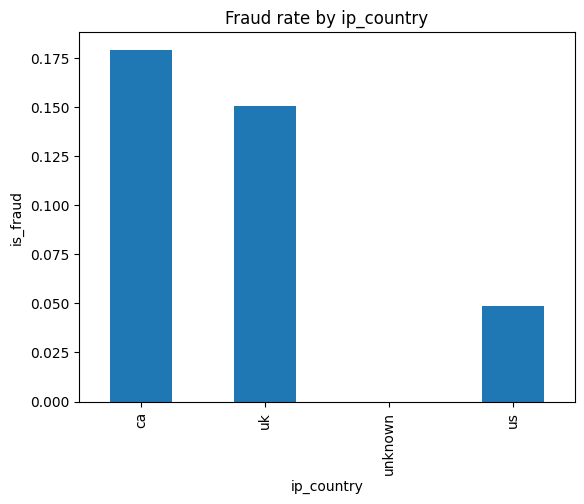

In [91]:
#the chart shows Fraud rate per ip_country
df.groupby('ip_country')['is_fraud'].mean().plot(kind='bar')
plt.xlabel('ip_country')
plt.ylabel('is_fraud')
plt.title('Fraud rate by ip_country')
plt.show()

ca (canada) has the highest rate of fraud transaction based on their ip.

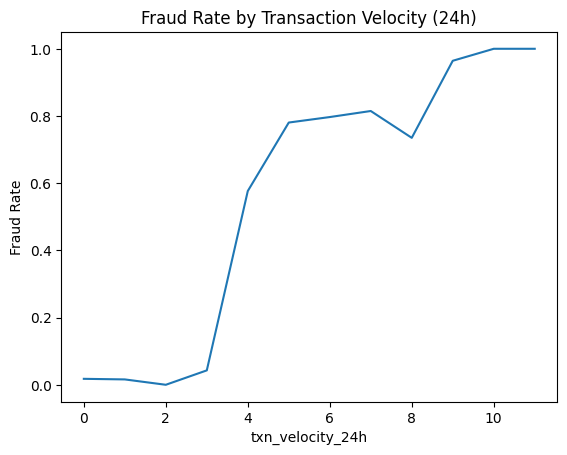

In [94]:
df.groupby('txn_velocity_24h')['is_fraud'].mean().plot()

plt.xlabel('txn_velocity_24h')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Transaction Velocity (24h)')

plt.show()

This chart reveals that Fraud increases with higher transaction velocity. Fraud spikes at specific velocity levels. This shows a strong correlation between how many transactions an account performs in a 24-hour period and the likelihood that those transactions are fraudulent.

For accounts making 0 to 3 transactions in a day, the fraud rate is nearly zero.
This represents typical, legitimate user behavior. The risk is extremely low in this range.

There is a massive jump starting at the 3rd transaction.
By the time an account reaches 5 transactions in 24 hours, the fraud rate climbs to roughly 75%. This suggests that "burst" activity is a major red flag for this specific dataset.

Between 5 and 8 transactions, the fraud rate stays relatively flat, hovering between 70% and 80%.
Interestingly, there is a slight "dip" around 8 transactions. This sometimes happens in data if there is a small cluster of very active legitimate users (power users), but the risk remains significantly higher than the baseline.

After 8 transactions, the curve spikes again, reaching nearly 1.0 (100%) by the 10th transaction. This clearly shows that any account performing 10 or more transactions in a single day is almost guaranteed to be fraudulent.



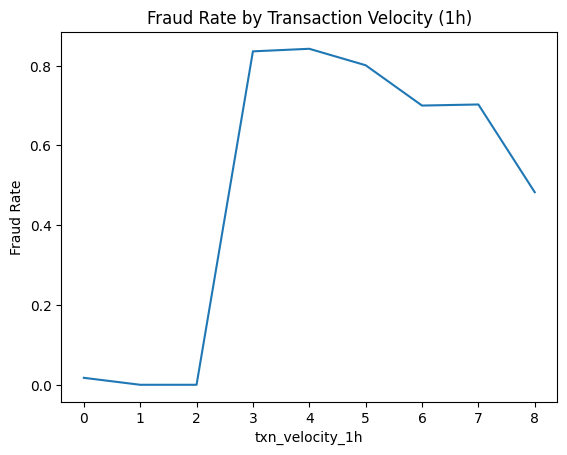

In [96]:
df.groupby('txn_velocity_1h')['is_fraud'].mean().plot()

plt.xlabel('txn_velocity_1h')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Transaction Velocity (1h)')

plt.show()

This chart, shows the relationship between how frequently a user makes transactions in one hour and the likelihood that those transactions are fraudulent.

When there are only 1 or 2 transactions per hour, the fraud rate is nearly zero. This represents "normal" or safe user behavior.
The Critical Jump: There is a massive spike between 2 and 3 transactions. Once a user hits that 3rd transaction within an hour, the probability of fraud jumps from near 0% to over 80%.

The fraud rate peaks and plateaus between 3 and 5 transactions per hour.
In this range, more than 70% to 80% of transactions are fraudulent. This suggests that "burst" activity—where many transactions happen in quick succession—is a primary indicator of a compromised account or a bot attack in your dataset.

After 5 transactions, the fraud rate begins to decline, dropping to about 45% by the 8th transaction.


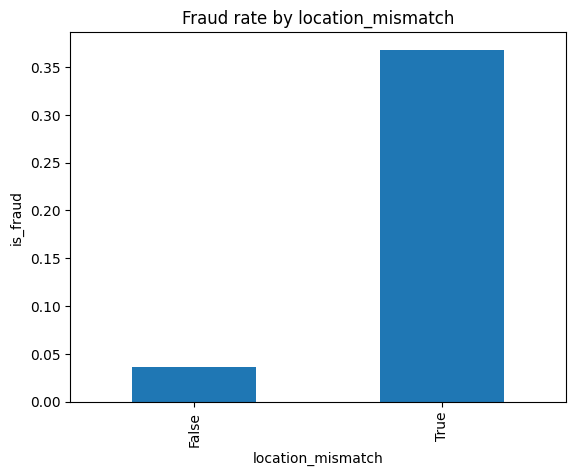

In [97]:
#the chart shows Fraud rate per location_mismatch
df.groupby('location_mismatch')['is_fraud'].mean().plot(kind='bar')
plt.xlabel('location_mismatch')
plt.ylabel('is_fraud')
plt.title('Fraud rate by location_mismatch')
plt.show()

This bar chart compares the likelihood of a transaction being fraudulent based on whether the transaction location matches the user's expected location.

location_mismatch = False: The transaction took place in a location consistent with the user's profile (e.g., their home city or a known frequent location).
location_mismatch = True: The transaction occurred in an unexpected or new location that doesn't align with the user's typical behavior.

When there is no location mismatch, the fraud rate is very low—appearing to be around 3–5% (0.03–0.05 on the y-axis). These are generally considered safe, routine transactions, whereas when a location mismatch is detected, the fraud rate spikes dramatically to over 35% (roughly 0.36).

A transaction with a location mismatch is roughly 7 to 9 times more likely to be fraudulent than one without a mismatch


From all of the above EDA charts, we can tell that variables like location_mismatch, channels, transaction_velocities, kyc_tier are very high-importance feature for our machine learning model.